
# Smart Waste Sorting System
**Project:** Smart Waste Sorting System  
**Student:** Philip Ayoreh  
**Course:** ITAI 1378  

This notebook builds an image classification model for waste sorting using **PyTorch** and **ResNet-50** transfer learning.

## What this notebook does
1. Installs/imports required libraries
2. Loads a waste image dataset from folders
3. Splits the dataset into training and validation sets
4. Trains a ResNet-50 classifier
5. Evaluates model performance
6. Shows sample predictions
7. Predicts the class of a single new image

## Expected dataset structure
Place your dataset in a folder like this:

```text
dataset/
├── cardboard/
├── glass/
├── metal/
├── paper/
├── plastic/
└── trash/
```

You can rename the main folder, but each class should be in its own subfolder.


In [ ]:
# If you are using Colab, uncomment the next line if needed:
# !pip install torch torchvision scikit-learn matplotlib pillow

import os
import copy
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Select GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("Using device:", device)


PyTorch version: 2.10.0+cu128
Using device: cuda


## 1. Set random seeds for reproducibility

In [ ]:

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)


In [ ]:
!pip install kaggle

In [8]:
import os

os.environ['KAGGLE_USERNAME'] = 'philipayoreh'
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_e083786992b068a1b0b3d21c5e56ae12'

In [10]:
!kaggle datasets download -d mostafaabla/garbage-classification

Dataset URL: https://www.kaggle.com/datasets/mostafaabla/garbage-classification
License(s): ODbL-1.0
100% 239M/239M [00:01<00:00, 126MB/s]



In [11]:
import zipfile

with zipfile.ZipFile("garbage-classification.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted!")

Dataset extracted!


In [12]:
import os

print(os.listdir("/content/dataset"))

['garbage_classification']


## 2. Define dataset path

In [15]:
import os, zipfile

DATA_DIR = "/content/dataset/Garbage classification"
extract_path = "/content/dataset"


print("Dataset extracted to:", extract_path)
print(os.listdir(extract_path))

Dataset extracted to: /content/dataset
['garbage_classification']


In [16]:
# Change this path to where your dataset is stored.
# Your dataset folder must contain one subfolder per class, for example:
# dataset/
#   cardboard/
#   glass/
#   metal/
#   paper/
#   plastic/
#   trash/

# Common locations to check automatically
possible_dataset_paths = [
    "dataset",
    "waste_dataset",
    "garbage_dataset",
    "/content/dataset",
    "/content/waste_dataset",
    "/content/garbage_dataset",
]

DATA_DIR = None
for path in possible_dataset_paths:
    if os.path.isdir(path) and any(Path(path).iterdir()):
        DATA_DIR = path
        break

# If your folder has a different name, set it manually here:
# DATA_DIR = "/content/your_dataset_folder"

if DATA_DIR is None:
    print("Dataset folder was not found.")
    print("Upload or unzip your image dataset first, then set DATA_DIR to that folder path.")
    print("Example: DATA_DIR = '/content/dataset'")
else:
    class_folders = sorted([p.name for p in Path(DATA_DIR).iterdir() if p.is_dir()])
    print("Dataset found:", DATA_DIR)
    print("Classes:", class_folders)


Dataset found: dataset
Classes: ['garbage_classification']


In [17]:
DATA_DIR = "dataset/garbage_classification"


In [18]:
from pathlib import Path

class_folders = sorted([
    p.name for p in Path(DATA_DIR).iterdir()
    if p.is_dir()
])

print("Classes:", class_folders)

Classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


In [33]:
import os
from pathlib import Path

DATA_DIR = "/content/dataset/garbage_classification"

class_folders = sorted([
    p.name for p in Path(DATA_DIR).iterdir()
    if p.is_dir()
])

print("Dataset found:", DATA_DIR)
print("Classes:", class_folders)

Dataset found: /content/dataset/garbage_classification
Classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


## 3. Create transforms and load the dataset

In [34]:
# Image transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

if DATA_DIR is None or not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(
        "DATA_DIR is not set correctly. Upload/unzip the dataset first, then rerun from the DATA_DIR cell."
    )

# Load dataset once for class names and splitting
full_dataset_for_split = datasets.ImageFolder(DATA_DIR)
class_names = full_dataset_for_split.classes
num_classes = len(class_names)

if num_classes < 2:
    raise ValueError("The dataset needs at least 2 class folders for image classification.")

if len(full_dataset_for_split) < 2:
    raise ValueError("The dataset needs at least 2 images before it can be split into train/validation sets.")

print("Class names:", class_names)
print("Number of classes:", num_classes)
print("Total images:", len(full_dataset_for_split))


Class names: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']
Number of classes: 12
Total images: 15515


## 4. Split into training and validation sets

In [35]:
# Create an 80/20 train-validation split
train_size = int(0.8 * len(full_dataset_for_split))
val_size = len(full_dataset_for_split) - train_size

# Make sure both splits contain at least one image
if train_size == 0 or val_size == 0:
    raise ValueError("Not enough images to create both training and validation sets.")

train_indices, val_indices = random_split(
    range(len(full_dataset_for_split)),
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(DATA_DIR, transform=val_transform)

train_subset = torch.utils.data.Subset(train_dataset, train_indices.indices)
val_subset = torch.utils.data.Subset(val_dataset, val_indices.indices)

BATCH_SIZE = 32
NUM_WORKERS = 0  # safer for Windows, Jupyter, and Colab. Increase to 2 later if desired.

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Training images:", len(train_subset))
print("Validation images:", len(val_subset))


Training images: 12412
Validation images: 3103


## 5. Visualize a few training images

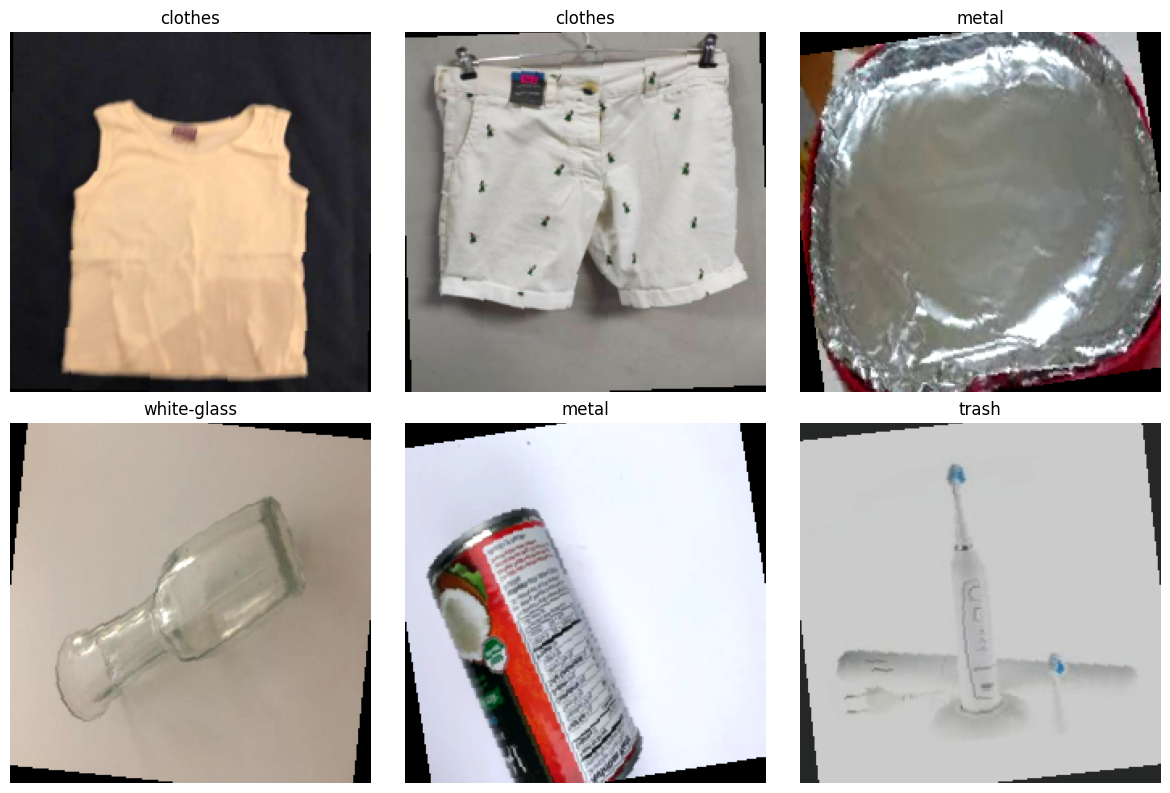

In [36]:
def imshow_tensor(img_tensor, title=None):
    img = img_tensor.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis("off")

images, labels = next(iter(train_loader))
plt.figure(figsize=(12, 8))

for i in range(min(6, len(images))):
    plt.subplot(2, 3, i + 1)
    imshow_tensor(images[i], class_names[labels[i].item()])

plt.tight_layout()
plt.show()


## 6. Build the model

In [37]:
# Load pretrained ResNet-50
weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)

# Freeze early layers for faster training
for param in model.parameters():
    param.requires_grad = False

# Replace the final classification layer for your waste classes
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

print("Model ready. Number of output classes:", num_classes)


Model ready. Number of output classes: 12


## 7. Train the model

In [38]:

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels).item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc


def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels).item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc, all_labels, all_preds


In [25]:

EPOCHS = 5

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_model_wts = copy.deepcopy(model.state_dict())
best_val_acc = 0.0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, y_true, y_pred = validate_one_epoch(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

model.load_state_dict(best_model_wts)
print(f"Best validation accuracy: {best_val_acc:.4f}")


Epoch 1/5
  Train Loss: 0.1173 | Train Acc: 0.9597
  Val Loss:   0.1234 | Val Acc:   0.9600
Epoch 2/5
  Train Loss: 0.1034 | Train Acc: 0.9658
  Val Loss:   0.1196 | Val Acc:   0.9610
Epoch 3/5
  Train Loss: 0.0950 | Train Acc: 0.9688
  Val Loss:   0.1138 | Val Acc:   0.9655
Epoch 4/5
  Train Loss: 0.0870 | Train Acc: 0.9707
  Val Loss:   0.1146 | Val Acc:   0.9629
Epoch 5/5
  Train Loss: 0.0844 | Train Acc: 0.9714
  Val Loss:   0.1064 | Val Acc:   0.9687
Best validation accuracy: 0.9687


## 8. Plot training history

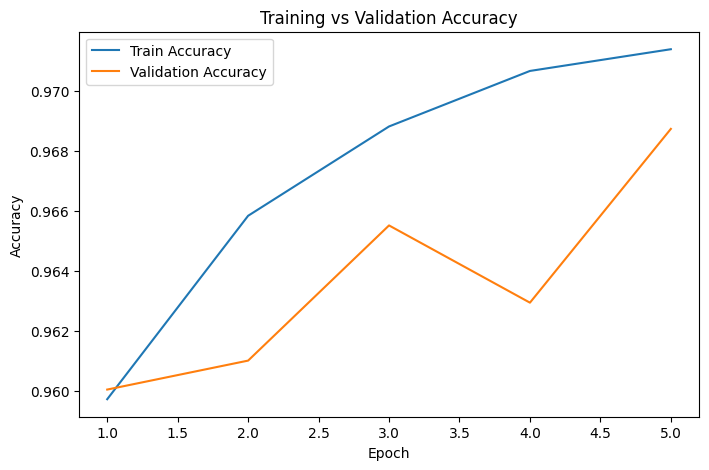

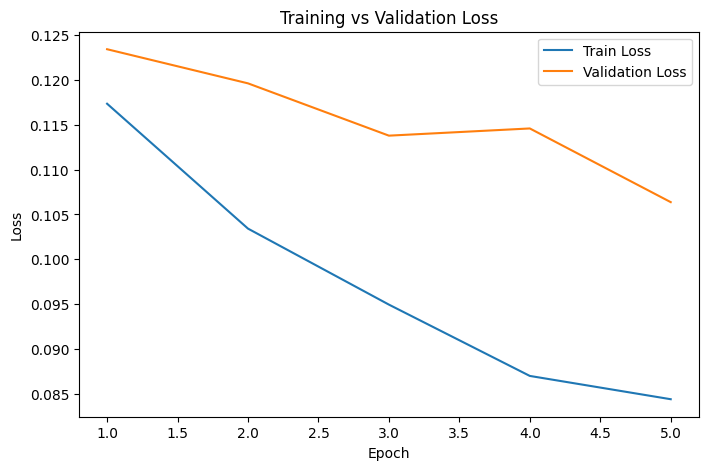

In [26]:

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


## 9. Evaluation report

In [27]:
val_loss, val_acc, y_true, y_pred = validate_one_epoch(model, val_loader, criterion, device)

print("Validation Accuracy:", round(val_acc * 100, 2), "%")
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


Validation Accuracy: 96.87 %

Classification Report:

              precision    recall  f1-score   support

     battery       0.95      0.98      0.96       209
  biological       0.98      0.98      0.98       179
 brown-glass       1.00      0.93      0.96       131
   cardboard       0.97      0.92      0.95       159
     clothes       1.00      0.98      0.99      1081
 green-glass       0.96      0.99      0.98       143
       metal       0.90      0.97      0.94       146
       paper       0.96      0.95      0.96       217
     plastic       0.92      0.91      0.91       159
       shoes       0.96      0.98      0.97       396
       trash       0.97      0.96      0.96       139
 white-glass       0.91      0.96      0.94       144

    accuracy                           0.97      3103
   macro avg       0.96      0.96      0.96      3103
weighted avg       0.97      0.97      0.97      3103



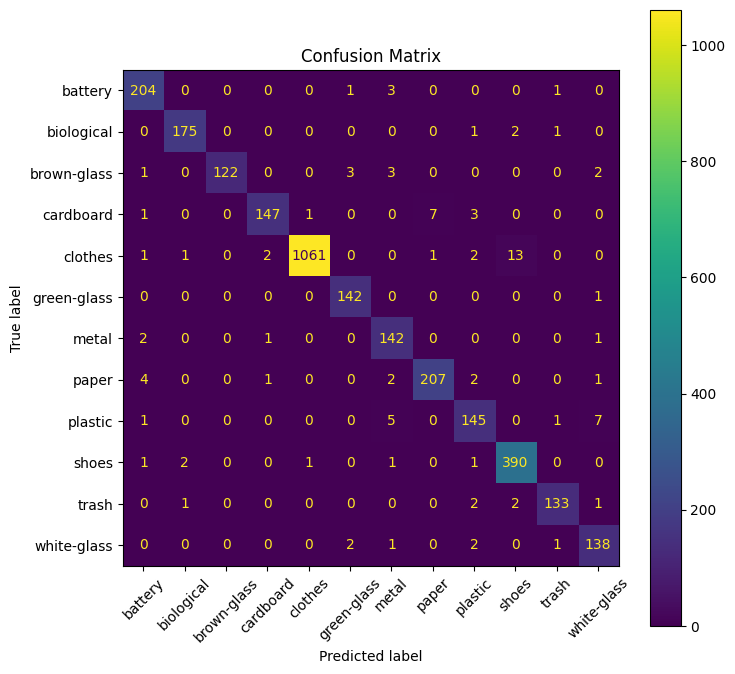

In [28]:

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


## 10. Show sample predictions

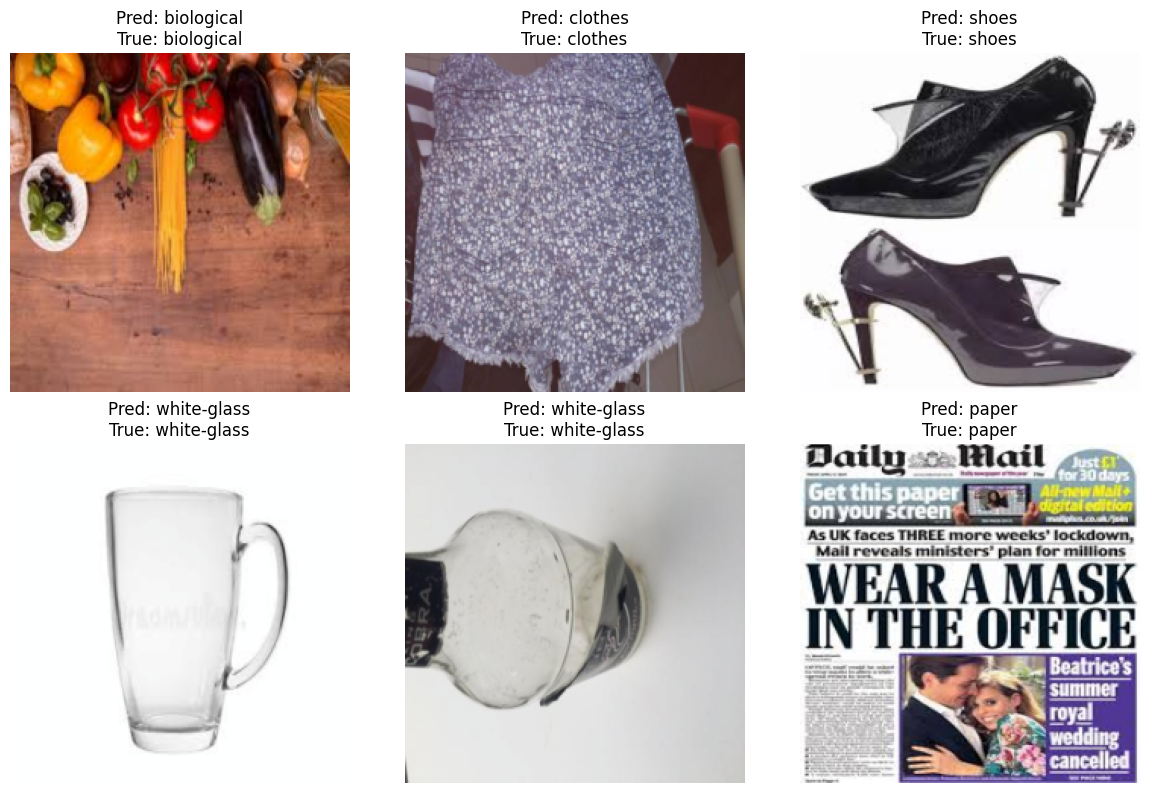

In [29]:
model.eval()
images, labels = next(iter(val_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

plt.figure(figsize=(12, 8))
for i in range(min(6, len(images))):
    plt.subplot(2, 3, i + 1)
    pred_label = class_names[preds[i].item()]
    true_label = class_names[labels[i].item()]
    imshow_tensor(images[i].cpu(), f"Pred: {pred_label}\nTrue: {true_label}")
plt.tight_layout()
plt.show()


## 11. Predict a single new image

In [30]:

def predict_image(image_path: str, model, class_names, device):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    tensor = val_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(tensor)
        probs = torch.softmax(outputs, dim=1)
        conf, pred = torch.max(probs, 1)

    predicted_class = class_names[pred.item()]
    confidence = conf.item()

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(f"Prediction: {predicted_class} ({confidence:.2%})")
    plt.axis("off")
    plt.show()

    return predicted_class, confidence

# Example:
# predict_image("test_image.jpg", model, class_names, device)


## 12. Save the trained model

In [39]:
import os

folders = [
    "results/images",
    "results/visualizations",
    "models/trained",
    "docs"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created.")

Folders created.


In [40]:
torch.save(model.state_dict(), "models/trained/smart_waste_model.pth")
print("Model saved.")

Model saved.


In [31]:

MODEL_PATH = "smart_waste_resnet50.pth"
torch.save(model.state_dict(), MODEL_PATH)
print("Model saved to:", MODEL_PATH)


Model saved to: smart_waste_resnet50.pth


In [41]:
from sklearn.metrics import classification_report, accuracy_score
import time
import numpy as np

model.eval()
all_preds = []
all_labels = []

start_time = time.time()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

end_time = time.time()

accuracy = accuracy_score(all_labels, all_preds)
avg_inference_time = (end_time - start_time) / len(all_labels)

print("Accuracy:", accuracy)
print("Average inference time per image:", avg_inference_time)

print(classification_report(all_labels, all_preds, target_names=class_names))

Accuracy: 0.061875604253947794
Average inference time per image: 0.006884326252520872
              precision    recall  f1-score   support

     battery       0.05      0.08      0.06       209
  biological       0.06      0.26      0.10       179
 brown-glass       0.06      0.44      0.11       131
   cardboard       0.00      0.00      0.00       159
     clothes       0.05      0.00      0.01      1081
 green-glass       0.02      0.01      0.01       143
       metal       0.12      0.02      0.04       146
       paper       0.06      0.19      0.09       217
     plastic       0.13      0.09      0.10       159
       shoes       0.00      0.00      0.00       396
       trash       0.09      0.01      0.02       139
 white-glass       0.12      0.02      0.04       144

    accuracy                           0.06      3103
   macro avg       0.06      0.10      0.05      3103
weighted avg       0.05      0.06      0.03      3103



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [43]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=class_names))

Accuracy: 0.061875604253947794
              precision    recall  f1-score   support

     battery       0.05      0.08      0.06       209
  biological       0.06      0.26      0.10       179
 brown-glass       0.06      0.44      0.11       131
   cardboard       0.00      0.00      0.00       159
     clothes       0.05      0.00      0.01      1081
 green-glass       0.02      0.01      0.01       143
       metal       0.12      0.02      0.04       146
       paper       0.06      0.19      0.09       217
     plastic       0.13      0.09      0.10       159
       shoes       0.00      0.00      0.00       396
       trash       0.09      0.01      0.02       139
 white-glass       0.12      0.02      0.04       144

    accuracy                           0.06      3103
   macro avg       0.06      0.10      0.05      3103
weighted avg       0.05      0.06      0.03      3103



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


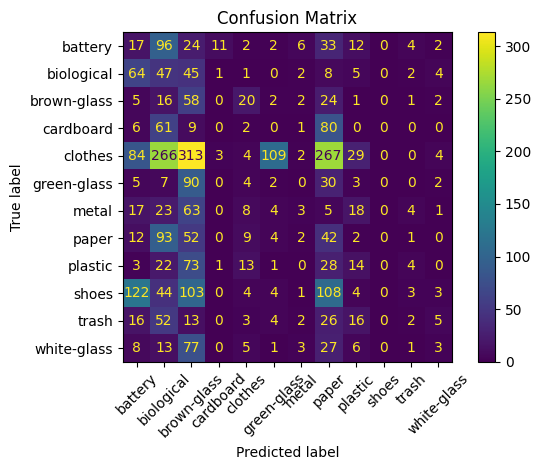

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_predictions(
    all_labels,
    all_preds,
    display_labels=class_names,
    xticks_rotation=45
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("results/visualizations/confusion_matrix.png")
plt.show()


## Notes for submission
You can use outputs from this notebook in your project report or presentation:
- dataset summary
- sample images
- training/validation accuracy curves
- confusion matrix
- example predictions

You can also add a small demo app later with Streamlit or Gradio.
